# Experiment 04 - Hopf bifurcation at the coexistence equilibrium P3

Paper section reproduced: Section 4, Theorem 4.3.

This notebook focuses on the full coexistence equilibrium `P3=(S3,x3,y3,z3)`. The bifurcation parameter is `lambda` in the nutrient-prey response function

`f1(S, lambda) = lambda*S/(b1+S)`.

The goal is to show that a complex conjugate pair of eigenvalues of the full 4x4 Jacobian crosses the imaginary axis, and that the long-run dynamics change from convergence to `P3` to sustained positive oscillations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

def monod(u, a, b):
    return a * u / (b + u)

def monod_prime(u, a, b):
    return a * b / (b + u)**2

base = dict(
    b1=0.9370061039733361,
    a2=2.888374760588028,
    b2=0.738617501015891,
    a3=3.053043755699016,
    b3=0.42655434585092505,
    D1=0.710494683597922,
    D2=0.7465315914916477,
    D3=0.2651586439982046,
)

def params(lam):
    p = dict(base)
    p["a1"] = lam
    return p

def rhs(t, U, p):
    S, x, y, z = U
    f1 = monod(S, p["a1"], p["b1"])
    f2 = monod(x, p["a2"], p["b2"])
    f3 = monod(y, p["a3"], p["b3"])
    return [
        1 - S - f1 * x,
        x * (f1 - p["D1"]) - f2 * y,
        y * (f2 - p["D2"]) - f3 * z,
        z * (f3 - p["D3"]),
    ]

def find_P3(lam, guess=(0.32, 0.87, 0.04, 0.12)):
    p = params(lam)
    sol = root(lambda U: rhs(0, U, p), guess)
    if not sol.success or np.any(sol.x <= 0):
        raise RuntimeError(f"Could not find positive P3 for lambda={lam}")
    return sol.x

def jacobian(U, p):
    S, x, y, z = U
    f1 = monod(S, p["a1"], p["b1"])
    f2 = monod(x, p["a2"], p["b2"])
    f3 = monod(y, p["a3"], p["b3"])
    f1p = monod_prime(S, p["a1"], p["b1"])
    f2p = monod_prime(x, p["a2"], p["b2"])
    f3p = monod_prime(y, p["a3"], p["b3"])
    return np.array([
        [-1 - f1p*x, -f1, 0, 0],
        [x*f1p, f1 - p["D1"] - f2p*y, -f2, 0],
        [0, y*f2p, f2 - p["D2"] - f3p*z, -f3],
        [0, 0, z*f3p, f3 - p["D3"]],
    ])

def simulate_lambda(lam, perturb=(1.03, 0.97, 1.04, 0.96), T=500):
    p = params(lam)
    U_star = find_P3(lam)
    U0 = U_star * np.array(perturb)
    return solve_ivp(lambda t, U: rhs(t, U, p), (0, T), U0, dense_output=True, max_step=0.1, rtol=1e-8, atol=1e-10), U_star

## Experiment 1: the positive equilibrium P3 exists

Before studying Hopf bifurcation, we verify that the equilibrium is an interior equilibrium with all components positive.

In [2]:
for lam in [2.7, 2.9, 3.1, 3.3]:
    P3 = find_P3(lam)
    print(f"lambda={lam:.2f}, P3={P3}")

lambda=2.70, P3=[0.38595049 0.7795673  0.04057003 0.11270337]
lambda=2.90, P3=[0.34788254 0.83054026 0.04057003 0.11968765]
lambda=3.10, P3=[0.31677694 0.87230761 0.04057003 0.12508111]
lambda=3.30, P3=[0.29085132 0.90719419 0.04057003 0.12937623]


## Experiment 2: eigenvalue crossing at P3

Theorem 4.3 requires a complex conjugate pair of eigenvalues to cross the imaginary axis. We track the dominant eigenvalue of the full 4x4 Jacobian at `P3(lambda)`.

Approximate crossing lambda: 2.960431654676259
Dominant eigenvalue near crossing: (4.0996786984957845e-05+0.472287975647793j)


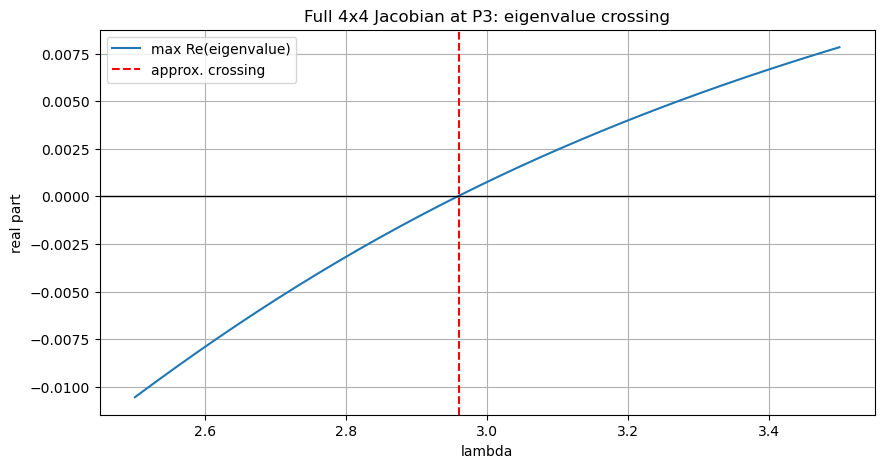

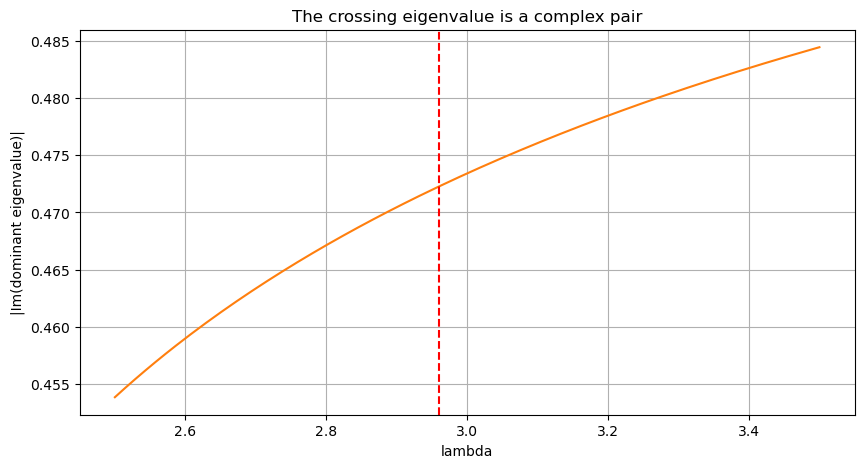

In [3]:
lams = np.linspace(2.5, 3.5, 140)
max_real = []
imag_part = []
dominant_eigs = []

guess = (0.32, 0.87, 0.04, 0.12)
for lam in lams:
    P3 = find_P3(lam, guess=guess)
    guess = P3
    eig = np.linalg.eigvals(jacobian(P3, params(lam)))
    dom = eig[np.argmax(eig.real)]
    dominant_eigs.append(dom)
    max_real.append(dom.real)
    imag_part.append(abs(dom.imag))

max_real = np.array(max_real)
imag_part = np.array(imag_part)
cross_idx = np.argmin(np.abs(max_real))
print("Approximate crossing lambda:", lams[cross_idx])
print("Dominant eigenvalue near crossing:", dominant_eigs[cross_idx])

plt.figure()
plt.plot(lams, max_real, label="max Re(eigenvalue)")
plt.axhline(0, color="black", lw=1)
plt.axvline(lams[cross_idx], color="red", ls="--", label="approx. crossing")
plt.xlabel("lambda")
plt.ylabel("real part")
plt.title("Full 4x4 Jacobian at P3: eigenvalue crossing")
plt.legend()
plt.show()

plt.figure()
plt.plot(lams, imag_part, color="tab:orange")
plt.axvline(lams[cross_idx], color="red", ls="--")
plt.xlabel("lambda")
plt.ylabel("|Im(dominant eigenvalue)|")
plt.title("The crossing eigenvalue is a complex pair")
plt.show()

## Experiment 3: time series before and after Hopf at P3

Before the crossing, perturbations decay toward `P3`. After the crossing, the trajectory displays sustained positive oscillations around the coexistence state.

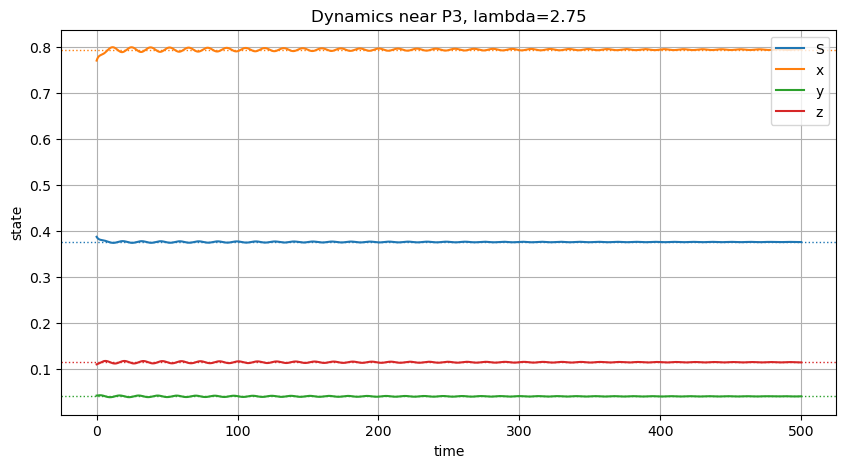

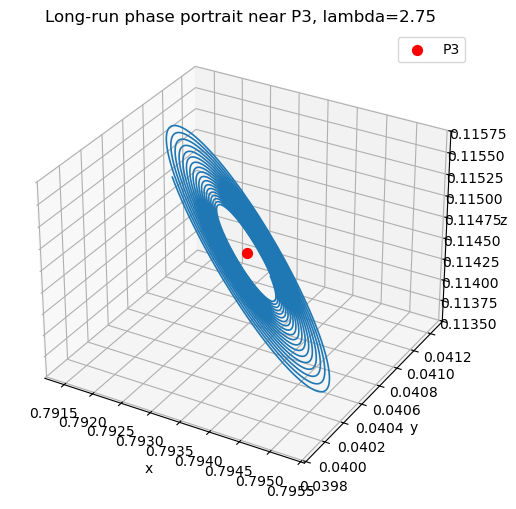

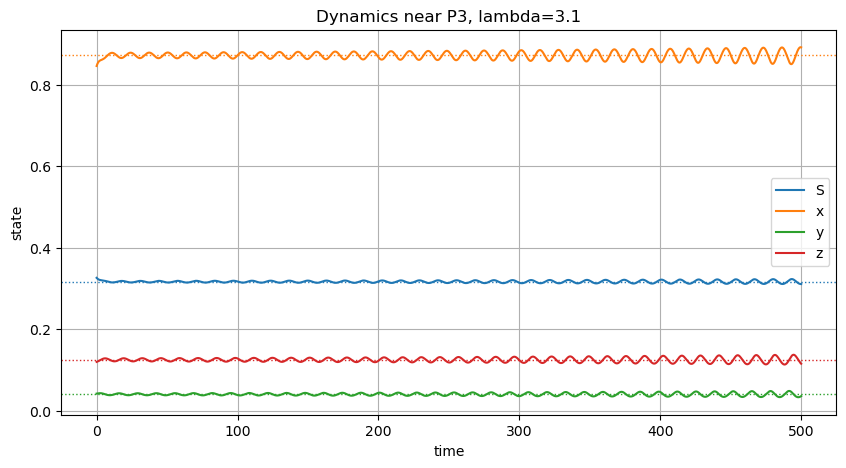

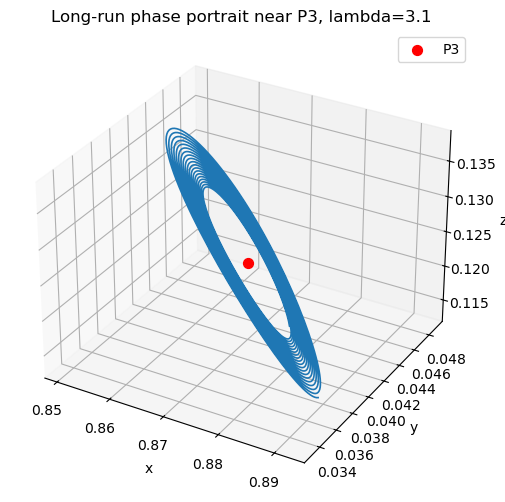

In [4]:
for lam in [2.75, 3.10]:
    sol, P3 = simulate_lambda(lam, T=500)
    t = np.linspace(0, 500, 4000)
    S, x, y, z = sol.sol(t)
    plt.figure(figsize=(10, 5))
    for arr, label in [(S, "S"), (x, "x"), (y, "y"), (z, "z")]:
        plt.plot(t, arr, label=label)
    plt.axhline(P3[0], color="tab:blue", ls=":", lw=1)
    plt.axhline(P3[1], color="tab:orange", ls=":", lw=1)
    plt.axhline(P3[2], color="tab:green", ls=":", lw=1)
    plt.axhline(P3[3], color="tab:red", ls=":", lw=1)
    plt.xlabel("time")
    plt.ylabel("state")
    plt.title(f"Dynamics near P3, lambda={lam}")
    plt.legend()
    plt.show()

    keep = t > 250
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(x[keep], y[keep], z[keep], lw=1.2)
    ax.scatter([P3[1]], [P3[2]], [P3[3]], color="red", s=50, label="P3")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"Long-run phase portrait near P3, lambda={lam}")
    ax.legend()
    plt.show()

## Experiment 4: numerical bifurcation diagram at P3

We discard the transient part and plot long-run maxima/minima of `x(t)`. A split between max and min branches indicates nonzero oscillation amplitude.

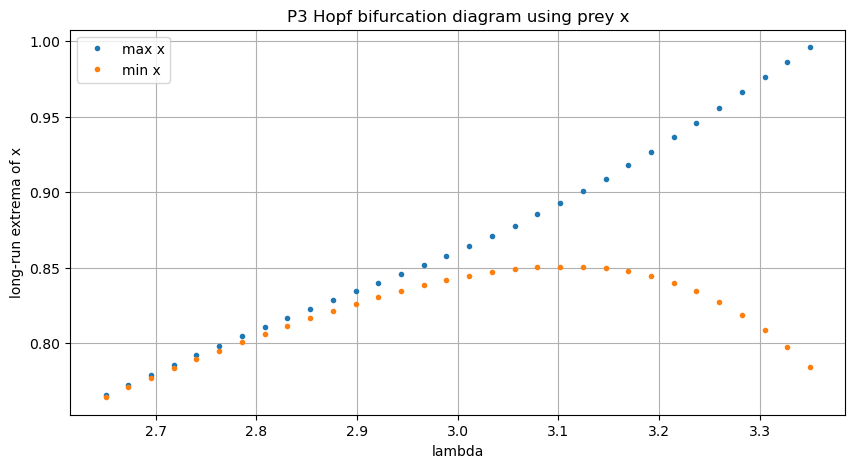

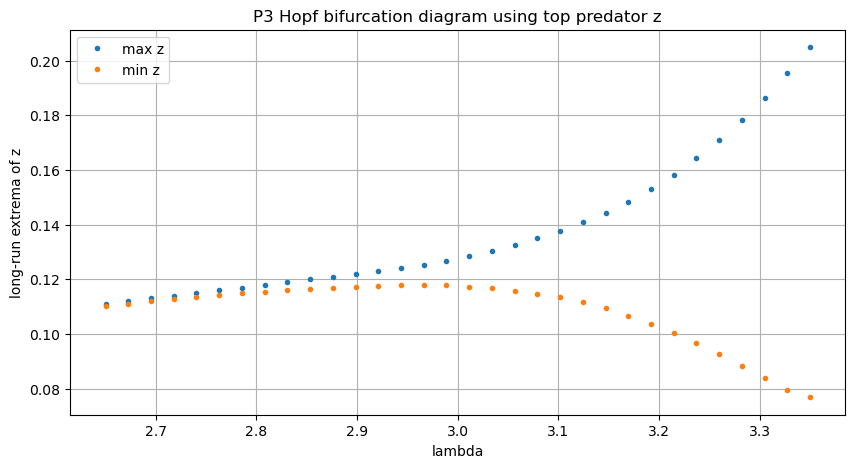

In [5]:
scan_lams = np.linspace(2.65, 3.35, 32)
x_max, x_min, y_max, y_min, z_max, z_min = [], [], [], [], [], []

for lam in scan_lams:
    sol, P3 = simulate_lambda(lam, T=500)
    t = np.linspace(300, 500, 2200)
    S, x, y, z = sol.sol(t)
    x_max.append(x.max()); x_min.append(x.min())
    y_max.append(y.max()); y_min.append(y.min())
    z_max.append(z.max()); z_min.append(z.min())

plt.figure()
plt.plot(scan_lams, x_max, ".", label="max x")
plt.plot(scan_lams, x_min, ".", label="min x")
plt.xlabel("lambda")
plt.ylabel("long-run extrema of x")
plt.title("P3 Hopf bifurcation diagram using prey x")
plt.legend()
plt.show()

plt.figure()
plt.plot(scan_lams, z_max, ".", label="max z")
plt.plot(scan_lams, z_min, ".", label="min z")
plt.xlabel("lambda")
plt.ylabel("long-run extrema of z")
plt.title("P3 Hopf bifurcation diagram using top predator z")
plt.legend()
plt.show()